<a href="https://colab.research.google.com/github/sys8815701-creator/AI_26/blob/main/04_01_%EB%A1%9C%EC%A7%80%EC%8A%A4%ED%8B%B1%ED%9A%8C%EA%B7%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# MBC 쇼핑몰에서 럭키백을 판매하기로 결정하였다.

# 럭키백의 대상은 생선으로, 총 7가지 어류가 무작위로 들어있다.
# 럭키백에 확률을 표시해야 한다. → 들어있는 7가지 생선의 확률이 필요하다.

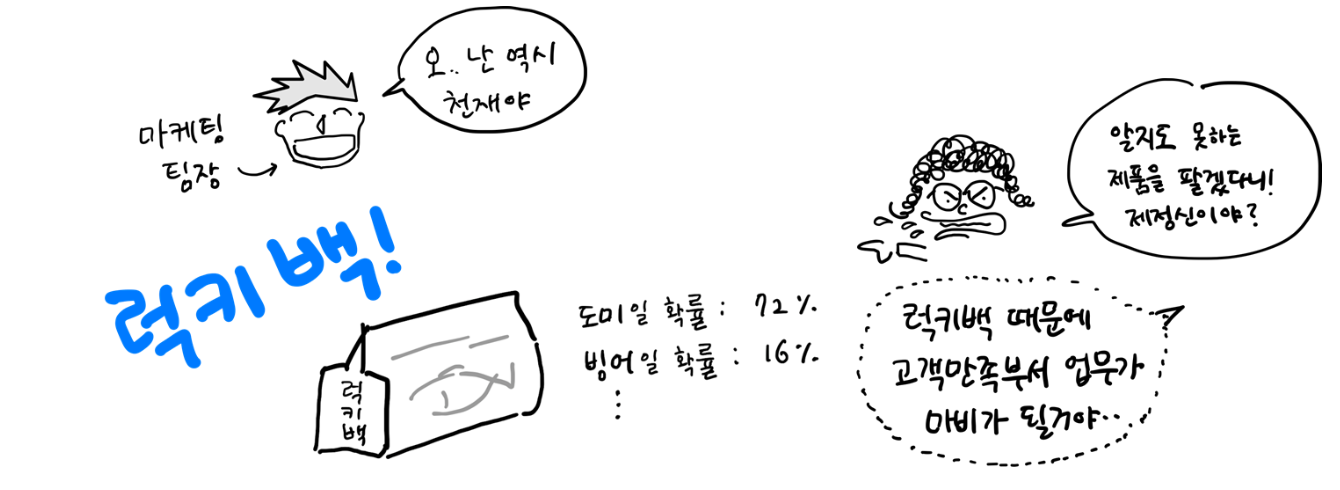

In [ ]:
# 럭키백의 확률 (생선이 총 7마리라고 가정한다.)
# 생선의 길이, 높이, 두께, 대각선의 길이, 무게

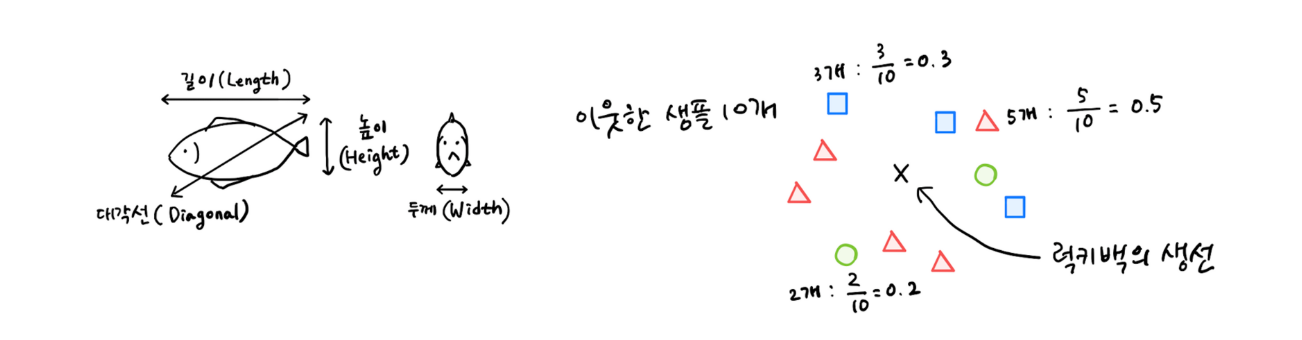

In [2]:
# 'K - 최근접 이웃 알고리즘' 中 회귀? 분류? → 확률을 알고 싶은 것이기 때문에, 회귀를 사용해보자.

# 샘플 10마리 中 농어가 3마리 → 3 / 10 == 0.3
# 빙어가 5마리 → 5 / 10 == 0.5
# 도미가 2마리 → 2 / 10 == 0.2
# 총 100%

# 사이킷런의 'K - 최근접 이웃 알고리즘' 中 분류도 이와 동일한 방식으로 확률을 계산한다.

# 샘플 데이터를 준비한다.
# 로지스틱 회귀 : 럭키백 확률
import pandas as pd # 판다스로 'csv'를 처리한다.

fish = pd.read_csv('https://bit.ly/fish_csv_data') # 웹에 있는 파일을 가져온다.
fish.head() # 제일 위쪽의 데이터 5개를 보여준다. → 어류, 무게, 길이, 대각선, 키, 너비(두께)

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [3]:
print(pd.unique(fish['Species'])) # 유니크하게 종류를 출력한다.

['Bream' 'Roach' 'Whitefish' 'Parkki' 'Perch' 'Pike' 'Smelt']


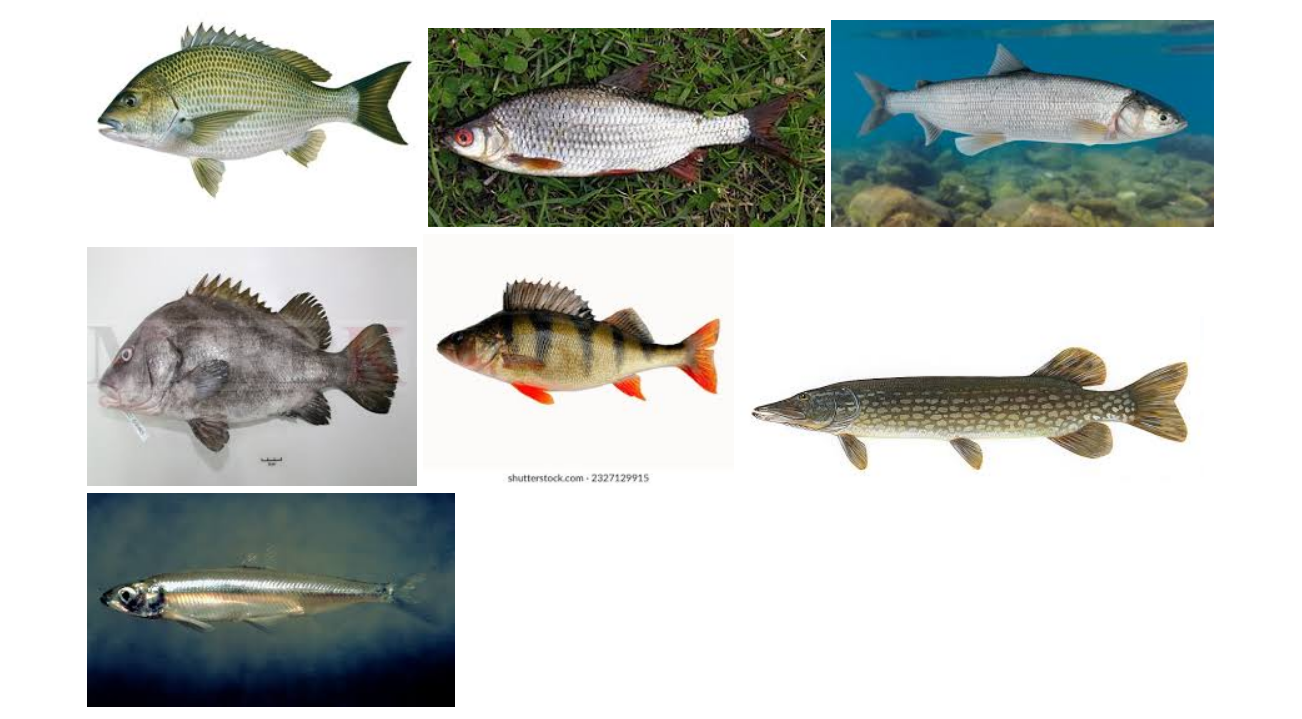

In [4]:
# Bream : 도미
# Roach : 유럽 잉어과 민물고기
# Whitefish : 흰살송어
# Parkki : 핀란드산 붕어과 어종
# Perch : 농어
# Pike : 강꼬치고기
# Smelt : 빙어

In [5]:
# 분석용 입력 리스트 값을 생성한다.
fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']].to_numpy()

# 원하는 필드를 넣어 필터링 한다.
print(fish_input[:5]) # 앞에서부터 5개만 출력한다.

[[242.      25.4     30.      11.52     4.02  ]
 [290.      26.3     31.2     12.48     4.3056]
 [340.      26.5     31.1     12.3778   4.6961]
 [363.      29.      33.5     12.73     4.4555]
 [430.      29.      34.      12.444    5.134 ]]


In [6]:
# 정답 리스트를 생성한다.
fish_target = fish['Species'].to_numpy()
# 만약 'fish[['Species']]'로 작성하면 2차원으로 배열된다. (금지) → 정답 파일은 1차원으로 배열해야 한다.
print(fish_target[:5])

['Bream' 'Bream' 'Bream' 'Bream' 'Bream']


In [7]:
# 훈련 세트를 생성한다.
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(
    fish_input, fish_target, random_state = 42
)
# fish_input ['Weight','Length','Diagonal','Height','Width'] : 2차원 배열
# fish_target ['Species'] : 1차원 배열

print(train_input.shape, test_input.shape)
# 결과 : 훈련용 → 119개의 5개 특성,
#        테스트용 → 40개의 5개 특성

(119, 5) (40, 5)


In [8]:
from sklearn.preprocessing import StandardScaler
# 표준 점수 : 데이터의 범위 (스케일 조정) = (값 - 평균) /  표준편차

ss = StandardScaler() # 사이킷런의 전처리용 (스케일 조정 : 표준 점수)
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)
print(train_scaled[:5])

[[ 0.91965782  0.60943175  0.81041221  1.85194896  1.00075672]
 [ 0.30041219  1.54653445  1.45316551 -0.46981663  0.27291745]
 [-1.0858536  -1.68646987 -1.70848587 -1.70159849 -2.0044758 ]
 [-0.79734143 -0.60880176 -0.67486907 -0.82480589 -0.27631471]
 [-0.71289885 -0.73062511 -0.70092664 -0.0802298  -0.7033869 ]]


In [9]:
# 'K - 최근접 이웃 알고리즘' 中 분류를 활용하여 확률을 예측한다.
from sklearn.neighbors import KNeighborsClassifier # 분류용

kn = KNeighborsClassifier(n_neighbors = 3) # 이웃한 데이터 中 3개를 참고한다.
kn.fit(train_scaled, train_target) # 훈련을 시작한다.

print(kn.score(train_scaled, train_target)) # 훈련 점수 : 약 89.07%
print(kn.score(test_scaled, test_target)) # 테스트 점수 : 약 85.00%

0.8907563025210085
0.85


In [10]:
# 전에는 0과 1을 찾는 이진 분류였지만, 지금은 타깃에 7개의 어류를 넣었다.
print(kn.classes_)
# 2개 이상의 클래스가 포함된 문제를 다중 분류라고 한다.
# 주의 사항 : 클래스의 순서가 인덱스로 되어 있으며, 이것이 오름차순 형태로 보인다.

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']


In [ ]:
print(kn.predict(test_scaled[:5])) # 0부터 4번까지의 인덱스를 확인한다.
# 처음 5개 샘플의 타깃값을 예측해보면 아래와 같다.

['Perch' 'Smelt' 'Pike' 'Perch' 'Perch']


In [11]:
print(test_scaled[:5]) # 전처리 과정에서 표준 점수로 변환되어 도출된다.

[[-0.88741352 -0.91804565 -1.03098914 -0.90464451 -0.80762518]
 [-1.06924656 -1.50842035 -1.54345461 -1.58849582 -1.93803151]
 [-0.54401367  0.35641402  0.30663259 -0.8135697  -0.65388895]
 [-0.34698097 -0.23396068 -0.22320459 -0.11905019 -0.12233464]
 [-0.68475132 -0.51509149 -0.58801052 -0.8998784  -0.50124996]]


In [12]:
import numpy as np # 특성에 대한 확률을 보기 위해서 변환한다.

# 사이킷런이 번거로운 연산을 수행해줌으로써, 수월하게 결과가 도출된다.
proba = kn.predict_proba(test_scaled[:5])
# proba : 각 클래스에 속할 '확률(Probability)'을 반환하는 함수 'predict_proba() Probability' 의 약어

print(np.round(proba, decimals = 4))
# 소수점 네 번째 자리까지 표시한다. (다섯 번째에서 반올림한다.)

[[0.     0.     1.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.     1.     0.    ]
 [0.     0.     0.     1.     0.     0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]]


In [ ]:
# Perch : 100%
# Smelt : 100%
# Pike : 100%
# Perch : 66.66%
# Perch : 66.66%
# 결과 : 이웃한 데이터 中 3개에 대한 분류 결과를 확인할 수 있다.

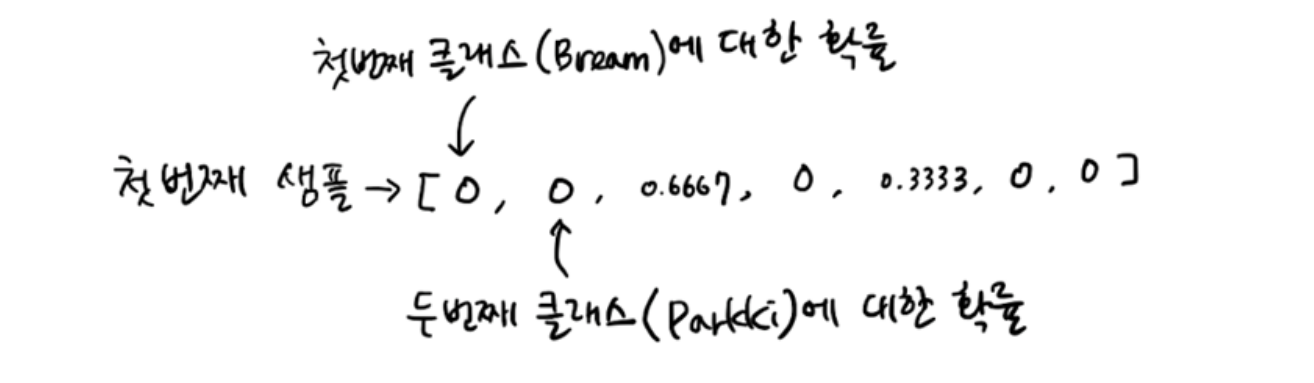

In [13]:
# 이 모델을 통해 계산한 확률 값이 가장 가까운 이웃의 비율과 일치하는지 확인해야 한다.
distances, indexes = kn.kneighbors(test_scaled[3:4]) # 4번째 값을 자세히 확인해보자.

print(train_target[indexes])
#                  Perch         Roach
#  [0.     0.     0.6667 0.     0.3333 0.     0.    ]
# 'n_neighbors = 3'으로 설정했기 때문에, 7개를 확률로 제공하지 못한다. (Perch 2/3 , Roach 1/3)
# 'kneighbors'의 한계점 : 더미데이터보다 더 높은 값이 들어올 경우 문제가 발생한다.

[['Roach' 'Perch' 'Perch']]


In [14]:
# 알고리즘을 변경해보자. → 로지스틱 회귀(LogisticRegression)
# from sklearn.linear_model import LogisticRegression
# 로지스틱 회귀 : 사이킷런에서 제공하는 회귀 모델로서, 회귀 모델인 동시에 분류 모델이다.

# 선형 회귀와 동일하게 선형 방정식을 학습한다.
# z = [a * (Weight)] + [b * (Length)] + [c * (Diagnal)] + [d * (Height)] + [e * (Width)] + f
# a, b, c, d, e, f : 각 항목에 대한 가중치 (중요도, 계수)
# z :  어떠한 값도 가능한 변수 (단, 확률이 되려면 0(0%)부터 1(100%)까지의 값이어야 한다.)
# z가 아주 큰 음수라면 0, 아주 큰 양수라면 1이 되도록 바꾸는 방법 : 시그모이드 함수 혹은 로지스틱 함수

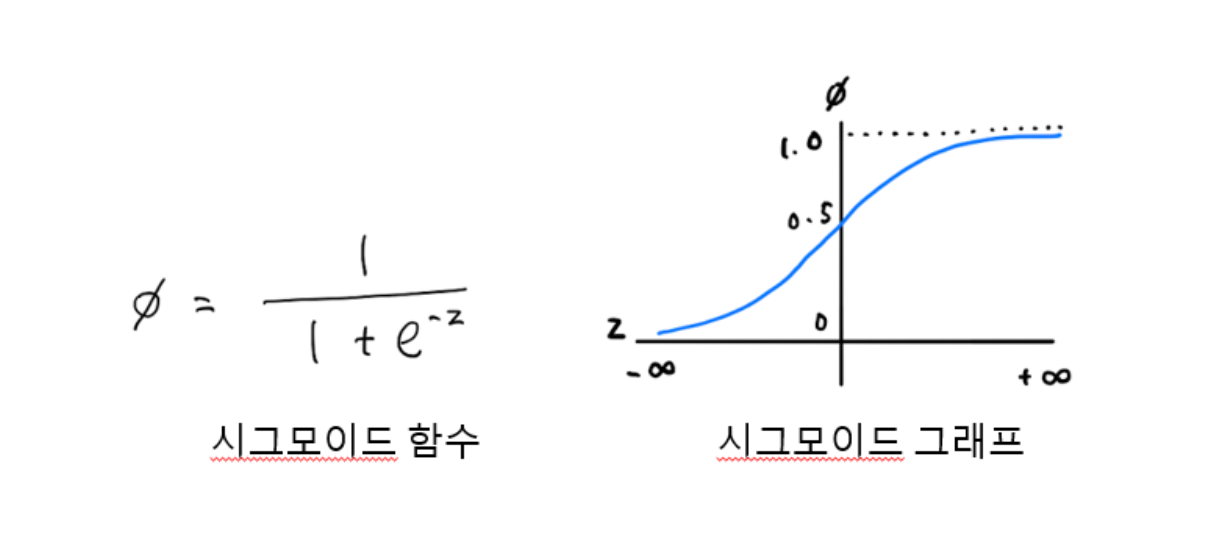

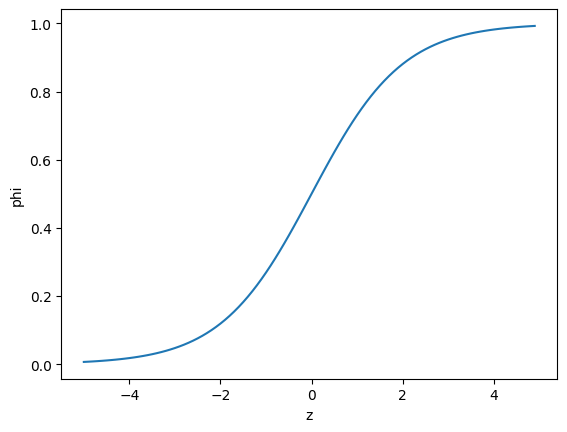

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 시그모이드 함수 : z가 무한하게 큰 음수일 경우 0에 가까워진다. <-> z가 무한하게 큰 양수일 경우 1에 가까워진다.
z = np.arange(-5, 5, 0.1) # -5부터 5까지, 0.1 간격으로 배열을 생성한다.
phi = 1 / (1 + np.exp(-z))

plt.plot(z, phi)
plt.xlabel('z')
plt.ylabel('phi')
plt.show()

In [ ]:
# 선형 방정식의 출력 : z의 음수를 활용하여 자연상수인 e를 거듭제곱하고, 1을 더한 값의 역수를 취한다. → 0부터 1까지의 값을 '0 ~ 100%' 확률로 해석할 수 있다.

# 훈련 전 2진 분류부터 알아 보자.
# 2진 분류인 경우, 시그모이드 함수 출력이 0.5보다 크면 양성, 0.5보다 작으면 음성으로 판단한다.
# 단, 0.5가 나오면 라이브러리마다 조금씩 다르지만 사이킷런은 음성으로 판단한다.

In [16]:
# 로지스틱 회귀를 활용한 이진 분류 수행 테스트

# 넘파이 배열은 True, False 값을 전달하여 행을 선택할 수 있다. (불리언 인덱싱)
char_arr = np.array(['A', 'B', 'C', 'D', 'E'])
print(char_arr[[True, False, True, False, False]]) # 불리언 인덱싱
# 결과 : True 값만 출력된다.

['A' 'C']


In [17]:
# 위와 동일한 방식으로, 훈련 세트에서 도미(Bream), 빙어(Smelt) 행만 골라내보자.
bream_smelt_indexes = (train_target == 'Bream') | (train_target == 'Smelt')
#                                       Bream(도미) or Smelt(빙어)

# 'bream_smelt_indexes'가 도미와 빙어일 경우 → True
# 나머지 → False

# 이 배열을 참고하여 'train_scaled', 'train_target' 배열에 인덱싱을 적용하면
train_bream_smelt = train_scaled[bream_smelt_indexes]
target_bream_smelt = train_target[bream_smelt_indexes]
# 결과 :도미와 빙어 데이터만 골라낼 수 있다.
print(train_bream_smelt)    # 도미 혹은 빙어의 특성 리스트

[[ 0.91965782  0.60943175  0.81041221  1.85194896  1.00075672]
 [-1.0858536  -1.68646987 -1.70848587 -1.70159849 -2.0044758 ]
 [ 0.63818253  0.56257661  0.73223951  1.64473401  0.50705737]
 [ 0.30041219  0.23459067  0.42823457  1.36042157  0.22329758]
 [ 0.9027693   0.70314202  0.88858491  1.89027545  0.85537174]
 [-1.0824759  -1.61150165 -1.62162731 -1.7000674  -1.92815631]
 [ 0.10337949  0.04717013  0.23714575  0.88445197  0.41799764]
 [ 1.49668216  1.03112796  1.21864741  2.44274986  1.40289707]
 [ 0.23004337  0.23459067  0.42823457  1.3336029   0.39983213]
 [-0.42579405 -0.29018684 -0.11028847  0.65627104 -0.26107519]
 [ 1.28557569  0.70314202  0.89727076  1.98228866  1.06683526]
 [ 0.93373158  0.60943175  0.83646978  1.85150445  0.97832415]
 [ 0.80706771  0.60943175  0.81041221  1.63137406  1.0255057 ]
 [-1.07262426 -1.52716241 -1.55214047 -1.67235972 -1.86207776]
 [ 1.6374198   1.17169337  1.27076255  2.41341232  1.40143407]
 [-1.07966115 -1.63961473 -1.67374245 -1.6462819  -1.87

In [18]:
print(target_bream_smelt) # 도미 혹은 빙어의 정답 리스트

['Bream' 'Smelt' 'Bream' 'Bream' 'Bream' 'Smelt' 'Bream' 'Bream' 'Bream'
 'Bream' 'Bream' 'Bream' 'Bream' 'Smelt' 'Bream' 'Smelt' 'Smelt' 'Bream'
 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Smelt' 'Bream'
 'Smelt' 'Smelt' 'Bream' 'Smelt' 'Bream' 'Bream']


In [19]:
# 사이킷런의 선형 모델에 로지스틱 회귀 클래스를 사용한다.
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression() # 로지스틱 회귀 객체를 변수에 연결한다.
lr.fit(train_bream_smelt, target_bream_smelt) # 훈련을 시작한다.
# 결과 : 2진 분류로 도출된다.(0.5 이하이면 False, 0.5 초과면 True)

LogisticRegression()

In [20]:
# 'train_bream_smelt'의 처음 5개 데이터의 값으로 결론을 내보자.
print(lr.predict(train_bream_smelt[:5])) # 도미 4마리 , 빙어 1마리

['Bream' 'Smelt' 'Bream' 'Bream' 'Bream']


In [21]:
# 확률을 확인한다. (predict_proba)
print(lr.predict_proba(train_bream_smelt[:5]))

[[0.99760007 0.00239993]
 [0.02737325 0.97262675]
 [0.99486386 0.00513614]
 [0.98585047 0.01414953]
 [0.99767419 0.00232581]]


In [22]:
# 샘플마다 2개의 확률이 출력된다. (시그모이드 함수)
# 첫 번째 열이 0(음성)에 대한 확률, 두 번째 열이 1(양성)에 대한 확률이다.
# 사이킷런의 타깃 값 : 알파벳 순으로 정렬하여 사용한다.
print(lr.classes_) # Smelt(빙어)가 양성으로 출력된다.
# 만약 도미(Bream)를 양성 클래스로 사용하고 싶다면, 전처리 과정에서 'Bream'인 타깃 값을 '1'로 만들어야 한다.

['Bream' 'Smelt']


In [23]:
# 로지스틱 회귀로 학습한 계수(가중치)를 확인해보자.
print(lr.coef_, lr.intercept_)
# 결과 : 선형 방정식에 대입하여 출력된다.
# 가중치 : z = [-0.40451732 * (Weight)] + [-0.57582787 * (Length)] + [-0.66248158 * (Diagonal)] + [-1.01329614 * (Height)] + [-0.73123131 * (Width)] + -2.16172774

[[-0.40451732 -0.57582787 -0.66248158 -1.01329614 -0.73123131]] [-2.16172774]


In [ ]:
z = -0.40451732 * (train_bream_smelt[0,0]) + -0.57582787 * (train_bream_smelt[0,1]) \
 + -0.66248158 * (train_bream_smelt[0,2]) + -1.01329614 * (train_bream_smelt[0,3]) \
 + -0.73123131 * (train_bream_smelt[0,4]) + -2.16172774
print(z)

-6.0299135794102545


In [24]:
# 'train_bream_smelt'의 처음 5개 데이터의 z 값을 출력해보자.
decisions = lr.decision_function(train_bream_smelt[:5])
print(decisions)
# 결과 : 각 특성을 계산한 z 결과 값이 출력된다.

[-6.02991358  3.57043428 -5.26630496 -4.24382314 -6.06135688]


In [25]:
# 이 z 값을 시그모이드 함수에 통과시키면 확률을 얻을 수 있다.
# 파이썬의 사이파이(scipy) 라이브러리에도 시그모이드 함수가 존재한다. → expit()
from scipy.special import expit

# 2개의 물고기를 분류하는 방법
print(expit(decisions)) # phi = 1 / (1 + np.exp(-z))

[0.00239993 0.97262675 0.00513614 0.01414953 0.00232581]


In [26]:
# 다중 분류로 진행해보자. → 현재 어류가 7종이므로, '로지스틱 회귀'로 분류를 학습시킨다.

# LogisticRegression 클래스 : 기본적으로 반복적인 알고리즘을 사용한다. (max_iter = 100)
# max_iter = 100 : 반복 횟수를 100으로 설정하면, 부족하다는 경고 문구가 나오고 1000으로 향상시킨다.
# LogisticRegression : 기본적으로 릿지 회귀와 같은 계수를 제곱하여 규제한다. (L2 규제)
# 릿지 회귀에서는 'alpha' 매개변수를 통해 규제의 양을 조절했다. → 'alpha'가 크면 규제도 커진다.
# LogisticRegression 규제를 제어하는 매개변수가 'C'로 되어있다. → 'C'가 작으면 규제가 커진다. (기본 1)
# 규제를 완화시키기 위해서 20으로 늘리고자 한다.

lr = LogisticRegression(C=20, max_iter=1000) # max_iter = 1000 : 정확도를 위해 1,000번 반복한다.
lr.fit(train_scaled, train_target)

print(lr.score(train_scaled, train_target)) # 약 93.27%
print(lr.score(test_scaled, test_target)) # 92.5%
# 결과 : 과소 혹은 과대 적합은 아니라고 추정된다.

0.9327731092436975
0.925


In [27]:
print(lr.predict(test_scaled[:5])) # 0부터 4번까지의 인덱스 결과 (분석 시 다중 분류로 출력된다.)

['Perch' 'Smelt' 'Pike' 'Roach' 'Perch']


In [28]:
proba = lr.predict_proba(test_scaled[:5]) # predict_proba() : 각 클래스에 속할 '확률'을 반환하는 함수
print(np.round(proba, decimals = 3))

[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]
 [0.011 0.034 0.305 0.006 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]


In [29]:
print(lr.classes_) # 알파벳 순으로 정렬된다.
# 결과 : 7개의 클래스가 명확하게 구분된다.

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']


In [31]:
# 다중 분류인 경우 선형 방정식
print(lr.coef_.shape, lr.intercept_.shape)
# (7, 5) : 7행을 가지고 5개의 특성을 사용한다.
# (7,) : 7개의 행 → 2진 분류에서 보았던 z를 7번 계산한다.
# 다중 분류 : 클래스마다 z 값을 하나씩 계산한다. → 가장 높은 z 값을 출력하는 클래스가 예측 클래스가 된다.

(7, 5) (7,)


In [ ]:
# 확률의 경우, 2진 분류에서는 시그모이드 함수를 활용하여 z를 0과 1사의 값으로 변환시켰다.
# 그러나 다중 분류에서는 소프트맥스 함수를 활용하여 7개의 z 값을 확률로 변환시킨다.

# 소프트맥스 계산 방법
# e_sum = e^z1 + e^z2 + e^z3 + e^z4 + e^z5 + e^z6 + e^z7
# s1 = e^z1 / e_sum ... s7 = e^z7 / e_sum → s1부터 s7까지 모두 더하면 분모가 같아지기 때문에 1이 된다.

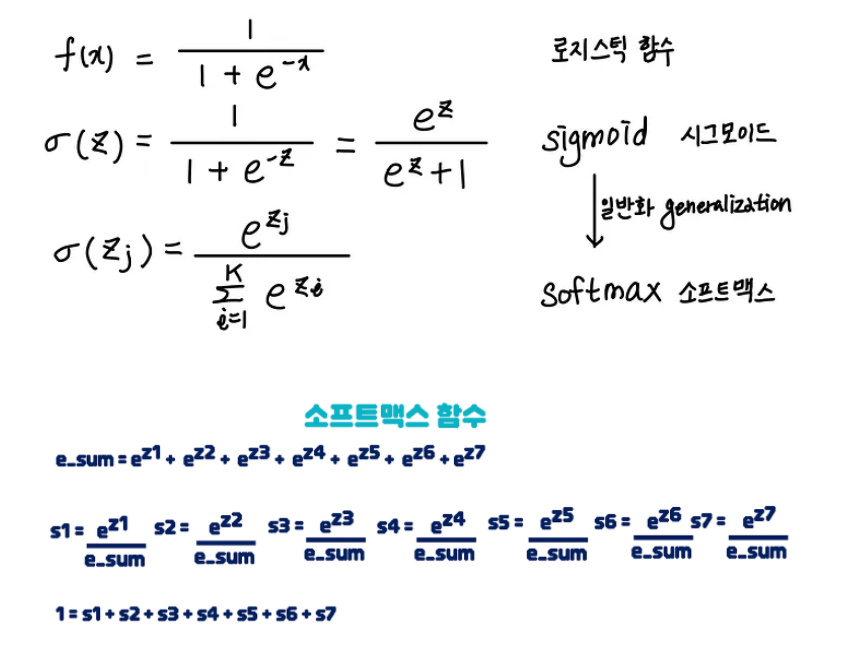

In [32]:
# 0 ~ 4번 인덱스의 테스트 리스트에서 결과를 출력한다.
decision = lr.decision_function(test_scaled[:5])
print("5개 샘플에 대한 z1부터 z7까지의 값")
for idx,z in enumerate(decision): # 선형 방정식를 활용한 7개 특성의 값
    print(f"{idx}번째 샘플의 z값\n{z}\n")

5개 샘플에 대한 z1부터 z7까지의 값
0번째 샘플의 z값
[-6.50722813  1.03902666  5.16819138 -2.75730346  3.33655201  0.34625858
 -0.62549703]

1번째 샘플의 z값
[-10.87900747   1.9441061    4.77600606  -2.42306183   2.98748716
   7.84171376  -4.24724379]

2번째 샘플의 z값
[-4.33809957 -6.23690282  3.16746648  6.48091391  2.36412675  2.43431897
 -3.87182372]

3번째 샘플의 z값
[-0.69143993  0.44628533  2.64291146 -1.21457286  3.2612452  -5.70143405
  1.25700485]

4번째 샘플의 z값
[-6.40138611 -1.99137623  5.81526372 -0.134644    3.49905133 -0.08753486
 -0.69937385]



In [33]:
from scipy.special import softmax # 소프트맥스 함수를 활용하여 7개를 100%로 분류한다.
print("소프트맥스 함수로 예측 확률 구하기")
class_ = lr.classes_.tolist() + ["예측 결과"]
prd = lr.predict(test_scaled[:5]).reshape(5, -1)
sm = softmax(decision, axis = 1).round(4) * 100
con = np.column_stack((sm, prd))
print(pd.DataFrame(con, columns= class_))

소프트맥스 함수로 예측 확률 구하기
  Bream Parkki  Perch   Pike  Roach  Smelt Whitefish  예측 결과
0   0.0   1.36   84.2   0.03  13.48   0.68      0.26  Perch
1   0.0   0.26   4.41    0.0   0.74  94.59       0.0  Smelt
2   0.0    0.0    3.4  93.44   1.52   1.63       0.0   Pike
3  1.09    3.4  30.54   0.65  56.68   0.01      7.64  Roach
4   0.0   0.04  90.43   0.24   8.92   0.25      0.13  Perch
